# Корреляция сигналов
Лабораторная работа 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 13, 'figure.figsize': (10, 3.6),
                     'axes.grid': True, 'axes.unicode_minus': False})

from scipy.signal import correlate, correlation_lags

## 2.1 Зачем сравнивать сигналы
Похожая форма может появиться в записях в разное время

## 2.2 Массивы и сумма произведений

In [2]:
a = np.array([1,2,0],dtype=float)
b = np.array([0,1,2],dtype=float)
print('a:',a)
print('b:',b)
print('Произведения:',a*b)
print('Сумма:',np.sum(a*b))

a: [1. 2. 0.]
b: [0. 1. 2.]
Произведения: [0. 2. 0.]
Сумма: 2.0


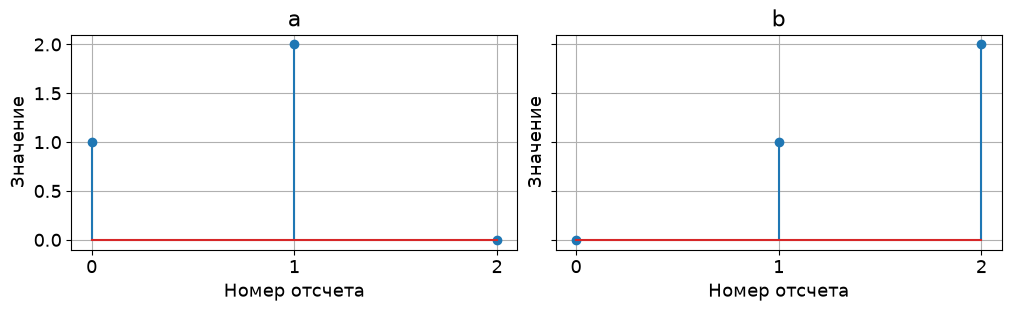

In [3]:
fig, axes = plt.subplots(1,2,figsize=(10,3),sharey=True,layout='constrained')
for ax,values,label in zip(axes,[a,b],['a','b']):
    ax.stem(np.arange(3),values)
    ax.set(title=label,xlabel='Номер отсчета',ylabel='Значение',xticks=[0,1,2])
plt.show()

## 2.3 Сдвиг и лаг
За границами массива используются нули

In [4]:
lag = -1
indices = np.arange(len(a))
shifted_b = np.array([b[n-lag] if 0 <= n-lag < len(b) else 0 for n in indices])
print('Лаг:',lag)
print('a:',a)
print('b со сдвигом:',shifted_b)
print('Произведения:',a*shifted_b)
print('Сумма:',np.sum(a*shifted_b))

Лаг: -1
a: [1. 2. 0.]
b со сдвигом: [1. 2. 0.]
Произведения: [1. 4. 0.]
Сумма: 5.0


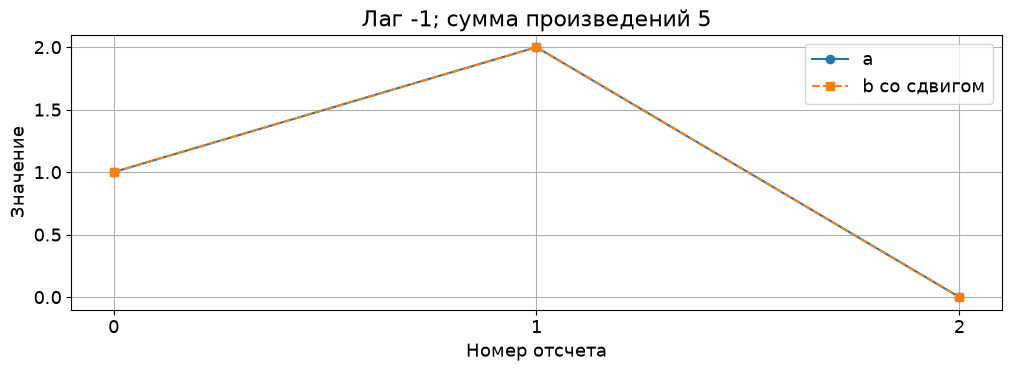

interactive(children=(IntSlider(value=0, description='lag', max=2, min=-2), Output()), _dom_classes=('widget-i…

In [5]:
from ipywidgets import interact, IntSlider

def shift_demo(lag=0):
    shifted = np.array([b[n-lag] if 0 <= n-lag < len(b) else 0 for n in indices])
    fig, ax = plt.subplots(layout='constrained')
    ax.plot(indices,a,'o-',label='a')
    ax.plot(indices,shifted,'s--',label='b со сдвигом')
    ax.set(xlabel='Номер отсчета',ylabel='Значение',xticks=indices,
           title=f'Лаг {lag}; сумма произведений {np.sum(a*shifted):g}')
    ax.legend()
    plt.show()

shift_demo(-1)
interact(shift_demo,lag=IntSlider(value=0,min=-2,max=2,step=1));

## 2.4 Корреляционная функция
Одна сумма произведений для каждого лага

In [6]:
lags = correlation_lags(len(a),len(b),mode='full')
r = correlate(a,b,mode='full')
print('Лаги:',lags)
print('Корреляция:',r)

Лаги: [-2 -1  0  1  2]
Корреляция: [2. 5. 2. 0. 0.]


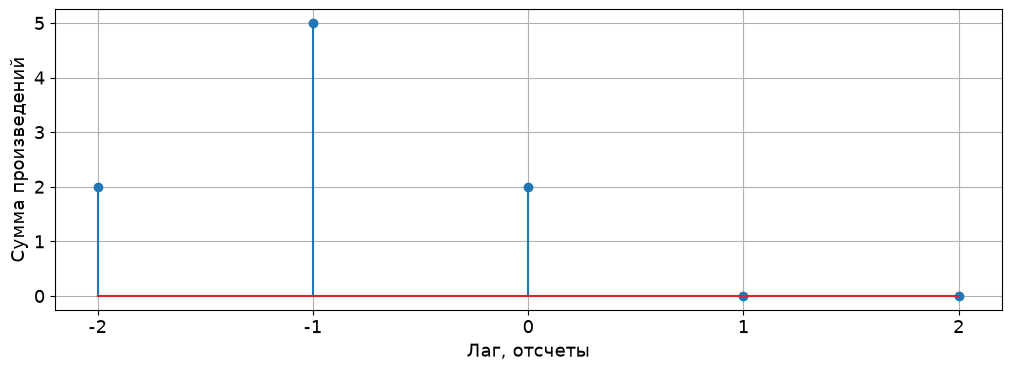

In [7]:
fig, ax = plt.subplots(layout='constrained')
ax.stem(lags,r)
ax.set(xlabel='Лаг, отсчеты',ylabel='Сумма произведений',xticks=lags)
plt.show()

## 2.5 Знак и единицы задержки

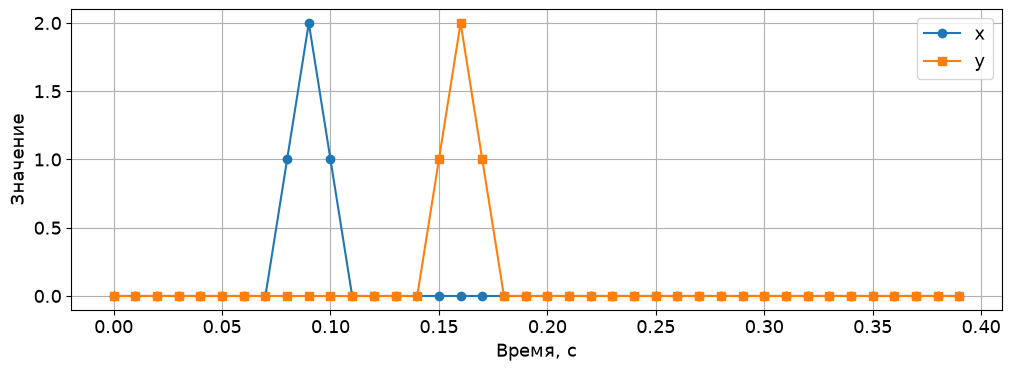

In [8]:
x = np.zeros(40)
y = np.zeros(40)
x[8:11] = [1,2,1]
y[15:18] = [1,2,1]
dt = 0.01
fig, ax = plt.subplots(layout='constrained')
ax.plot(np.arange(40)*dt,x,'o-',label='x')
ax.plot(np.arange(40)*dt,y,'s-',label='y')
ax.set(xlabel='Время, с',ylabel='Значение'); ax.legend()
plt.show()

Лаг пика correlate(x,y): -7
Задержка y относительно x, с: 0.07


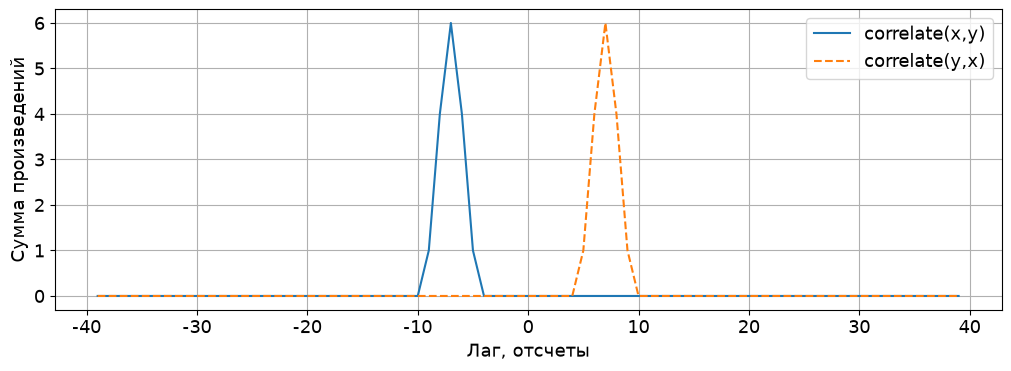

In [9]:
lags = correlation_lags(len(x),len(y),mode='full')
r_xy = correlate(x,y,mode='full')
r_yx = correlate(y,x,mode='full')
peak_lag = lags[np.argmax(r_xy)]
print('Лаг пика correlate(x,y):',peak_lag)
print('Задержка y относительно x, с:',-peak_lag*dt)
fig, ax = plt.subplots(layout='constrained')
ax.plot(lags,r_xy,label='correlate(x,y)')
ax.plot(lags,r_yx,'--',label='correlate(y,x)')
ax.set(xlabel='Лаг, отсчеты',ylabel='Сумма произведений'); ax.legend()
plt.show()

## 2.6 Среднее значение и центрирование

Исходные значения: [ 9. 10. 11.]
Среднее: 10.0
После центрирования: [-1.  0.  1.]


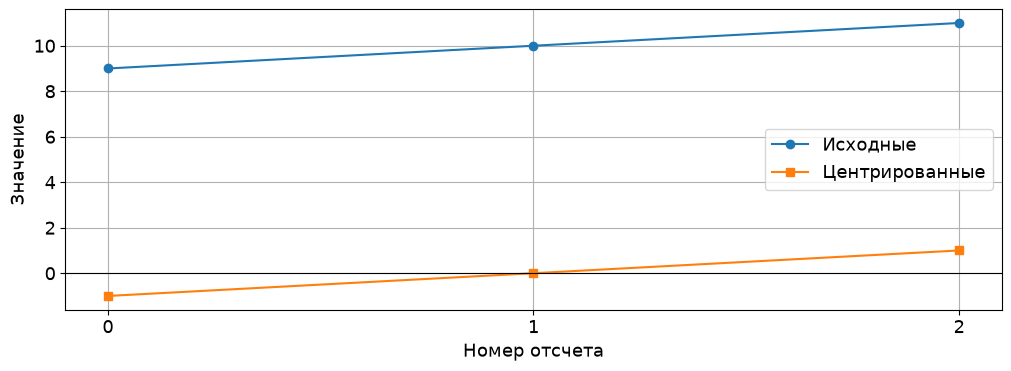

In [10]:
values = np.array([9.,10.,11.])
centered = values-values.mean()
print('Исходные значения:',values)
print('Среднее:',values.mean())
print('После центрирования:',centered)
fig, ax = plt.subplots(layout='constrained')
ax.plot(np.arange(3),values,'o-',label='Исходные')
ax.plot(np.arange(3),centered,'s-',label='Центрированные')
ax.axhline(0,color='black',linewidth=0.8)
ax.set(xlabel='Номер отсчета',ylabel='Значение',xticks=[0,1,2]); ax.legend()
plt.show()

## 2.7 Энергия и нормировка
Сумма квадратов задает масштаб массива

In [11]:
print('Квадраты a:',a*a)
print('Энергия a:',np.sum(a*a))
print('Масштаб a:',np.linalg.norm(a))
print('Делитель для a и b:',np.linalg.norm(a)*np.linalg.norm(b))

Квадраты a: [1. 4. 0.]
Энергия a: 5.0
Масштаб a: 2.23606797749979
Делитель для a и b: 5.000000000000001


In [12]:
from scipy.signal import correlate, correlation_lags

def normalized_correlation(a, b, center=True):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if center:
        a = a - a.mean()
        b = b - b.mean()
    denominator = np.linalg.norm(a)*np.linalg.norm(b)
    if denominator == 0:
        raise ValueError('Нулевая энергия: нормированная корреляция не определена')
    return correlate(a, b, mode='full')/denominator

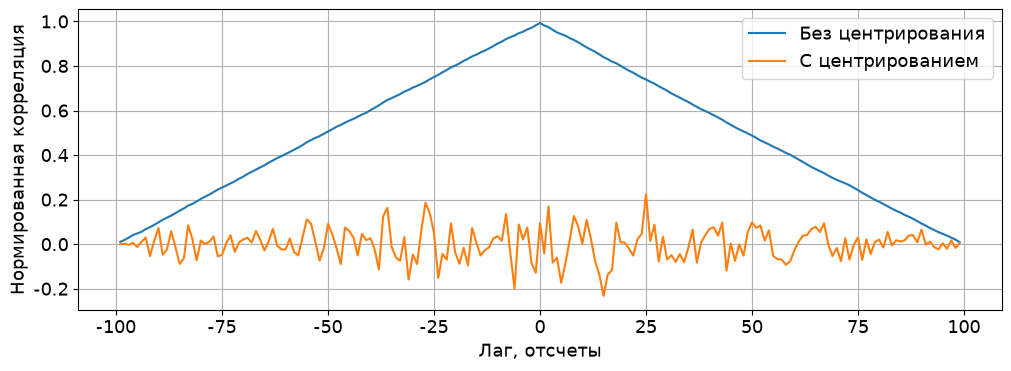

In [13]:
rng = np.random.default_rng(42)
x = 10+rng.normal(size=100)
y = 10+rng.normal(size=100)
lags = correlation_lags(len(x),len(y),mode='full')
raw = correlate(x,y,mode='full')/(np.linalg.norm(x)*np.linalg.norm(y))
centered_r = normalized_correlation(x,y)
fig, ax = plt.subplots(layout='constrained')
ax.plot(lags,raw,label='Без центрирования')
ax.plot(lags,centered_r,label='С центрированием')
ax.set(xlabel='Лаг, отсчеты',ylabel='Нормированная корреляция'); ax.legend()
plt.show()

## 2.8 Автокорреляция
Сравнение сигнала с его собственной сдвинутой копией

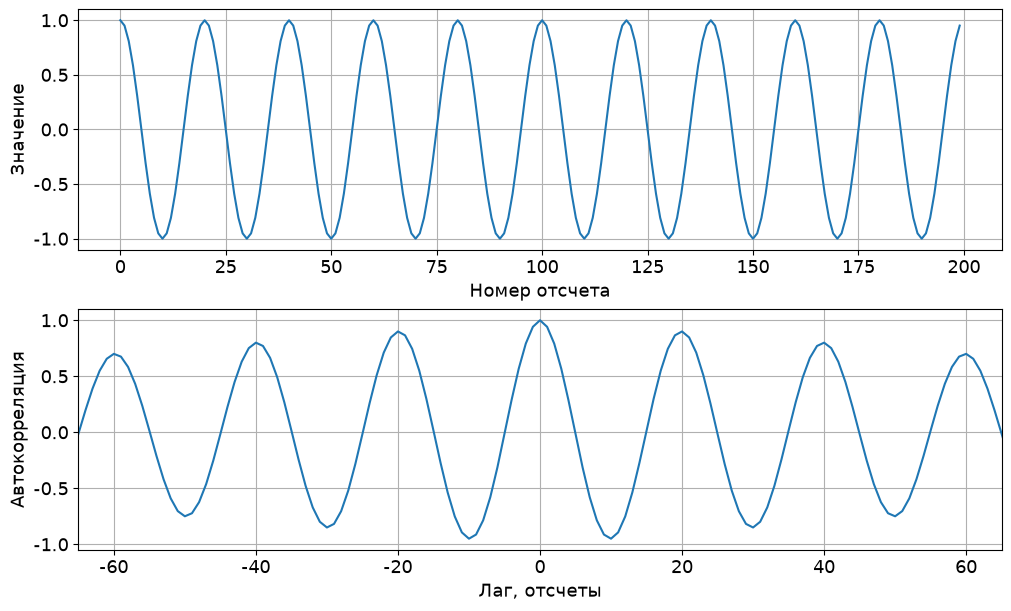

In [14]:
n = np.arange(200)
periodic = np.cos(2*np.pi*n/20)
fig, axes = plt.subplots(2,1,figsize=(10,6),layout='constrained')
axes[0].plot(n,periodic)
axes[0].set(xlabel='Номер отсчета',ylabel='Значение')
auto_lags = correlation_lags(len(periodic),len(periodic),mode='full')
axes[1].plot(auto_lags,normalized_correlation(periodic,periodic))
axes[1].set(xlabel='Лаг, отсчеты',ylabel='Автокорреляция',xlim=(-65,65))
plt.show()

## 2.9 Ограничения линейной корреляции
Нулевой коэффициент не исключает зависимости

Коэффициент Пирсона: 1.3639926937433163e-16


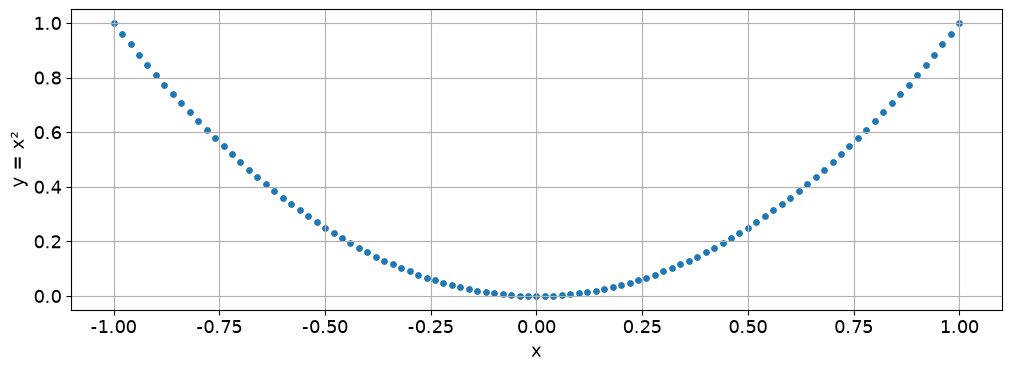

In [15]:
x = np.linspace(-1,1,101)
y = x*x
print('Коэффициент Пирсона:',np.corrcoef(x,y)[0,1])
fig, ax = plt.subplots(layout='constrained')
ax.scatter(x,y,s=15)
ax.set(xlabel='x',ylabel='y = x²')
plt.show()

## 2.10 Сетка и модель лабораторной
100 точек, 99 промежутков

In [16]:
t = np.linspace(0,10,100)
dt = t[1]-t[0]
print('Число точек:',len(t))
print('Начало сетки:',t[:5])
print('Шаг:',dt)
print('Лаг 3 в единицах t:',3*dt)

Число точек: 100
Начало сетки: [0.        0.1010101 0.2020202 0.3030303 0.4040404]
Шаг: 0.10101010101010101
Лаг 3 в единицах t: 0.30303030303030304


## Лабораторная работа
[Теория](THEORY.md) | [Задание](README.md) | [Шаблон](lab2.ipynb)